# 26회차 기출문제

## 문제 1

**Data description**

-   **Invoice_no** : 송장번호

-   **Stock_code** : 제품코드

-   **Stock_category** : 제품 분류

-   **Quantity** : 수량

-   **Invoice_date** : 주문일자

-   **Unit_price** : 단가

-   **Customer_id** : 고객번호

-   **Country** : 국가

#### 데이터 셋:problem1.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/refs/heads/master/adp/26/problem1.csv')
print(df.info())
display(df.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35801 entries, 0 to 35800
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    35801 non-null  object 
 1   StockCode    35801 non-null  object 
 2   Description  35801 non-null  object 
 3   Quantity     35776 non-null  float64
 4   InvoiceDate  35801 non-null  object 
 5   UnitPrice    35704 non-null  float64
 6   CustomerID   35801 non-null  float64
 7   Country      35801 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.2+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,563808,22432,WATERING CAN PINK BUNNY,6.0,8/19/2011 11:46,1.95,12626.0,Germany
1,561645,23166,MEDIUM CERAMIC TOP STORAGE JAR,12.0,7/28/2011 15:16,1.25,14911.0,EIRE


1.  **결측치 처리하시오.**

Quantity에 16개의 결측치가 있는 것을 확인할 수 있다. 결측치가 전체 데이터 대비 아주 적은 비율로 모델학습에 큰 영향을 주지 않으므로 삭제한다.   

In [4]:
df.isna().sum()/len(df)*100

InvoiceNo      0.000000
StockCode      0.000000
Description    0.000000
Quantity       0.069830
InvoiceDate    0.000000
UnitPrice      0.270942
CustomerID     0.000000
Country        0.000000
dtype: float64

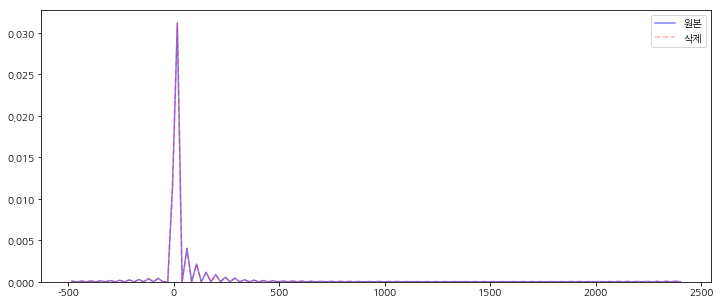

In [5]:
df1 = df.copy()
df1 = df1.dropna()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.kdeplot(data=df['Quantity'], ax=ax, ls='-', color='b', label='원본', alpha=0.5)
sns.kdeplot(data=df1['Quantity'], ax=ax, ls='--', color='r', label='삭제', alpha=0.3)
plt.show()

2.  **고객 데이터를 활용하여 군집분석을 수행하려고 한다. 군집분석 수행 전에 이상치를 제거하려고 한다. 이상치를 제거하는 방법을 설명하고, 이상치를 제거한 후 이상치가 모두 제거되었다는 통계 자료를 제시하시오.**

1. 사분위수와 IQR 활용 이상치 탐지
2. zscore +-3: 간편함

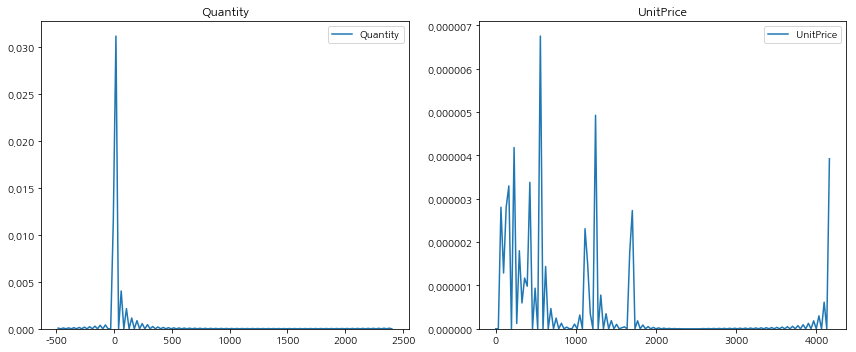

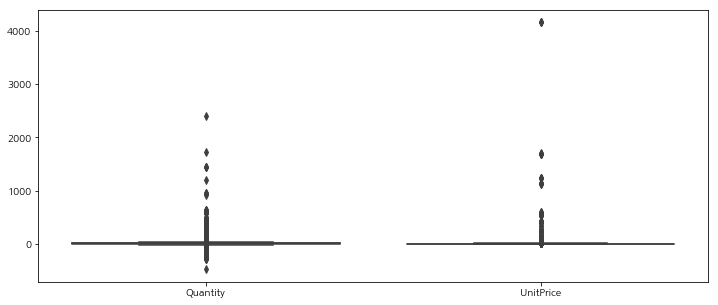

In [6]:
n_cols = df1.select_dtypes('number').columns[:-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, ax in zip(n_cols, axes):
    sns.kdeplot(data=df1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df1[n_cols])
plt.show()

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,35776.0,18.426040,42.162427,-480.0,4.00,10.00,16.00,2400.00
UnitPrice,35704.0,4.612001,48.082538,0.0,1.25,1.95,3.75,4161.06
CustomerID,35801.0,13221.824390,1012.177727,12354.0,12523.00,12681.00,14156.00,17097.00


In [8]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

수량은 음수일 수 없는데, 음수값이 다수 관찰된다. 0 이하의 값을 삭제한다.  
물품단가가 0인 값이 관찰된다. 우수고객 대상 사은품으로 책정되었을 수도 있기 때문에 삭제하지 않는다.

In [9]:
z_code.values

NameError: name 'z_code' is not defined

In [10]:
#물품단가가 0인 물품 하나의 가격 확인(22619)

z_code = df1.loc[df1['UnitPrice'] == 0, 'StockCode'].head(1)

df1[df1['StockCode'].isin(z_code.values)].sort_values(by='UnitPrice', ascending=True).head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2794,574252,M,Manual,1.0,11/3/2011 13:24,0.00,12437.0,France
24207,577168,M,Manual,1.0,11/18/2011 10:42,0.00,12603.0,Germany
618,C564899,M,Manual,-480.0,8/31/2011 11:31,0.22,14646.0,Netherlands
32164,C580263,M,Manual,-16.0,12/2/2011 12:43,0.29,12536.0,France
34510,C557300,M,Manual,-1.0,6/19/2011 14:05,0.77,12421.0,Spain


물품단가가 0인 품목의 물품단가는 다르다. 고객 증정용 사은품으로 추측할 수 있다.

In [11]:
# 일단 사분위 기준

ds = df.describe().T
q1 = ds['25%']
q3 = ds['75%']
iqr = q3 - q1

low = q1 - (1.5*iqr)
high = q3 + (1.5*iqr)

print(f"상단값:\n {high}\n")
print(f"하단값:\n {low}\n")


for col in n_cols:
    err = df1[(df1[col] > high[col]) | (df1[col] < low[col])]
    print(f"{col} 이상치 개수: {len(err)}")

상단값:
 Quantity         34.0
UnitPrice         7.5
CustomerID    16605.5
dtype: float64

하단값:
 Quantity        -14.0
UnitPrice        -2.5
CustomerID    10073.5
dtype: float64

Quantity 이상치 개수: 3721
UnitPrice 이상치 개수: 4332


사분위수 범위로 판별한 이상치는 지나치게 개수가많다.   
모두 삭제하면 데이터 손실이 커져 모델 학습성능 저하로 이어질 수 있음

In [12]:
#zscore 기준

from scipy.stats import zscore

for col in n_cols:
    z = np.abs(zscore(df1[col]))
    err = df1.loc[z>3, col]
    print(f"{col} 이상치 개수: {len(err)}")

Quantity 이상치 개수: 475
UnitPrice 이상치 개수: 41


위 사분위수보다는 이상치 개수가 줄어들었지만, 해당 데이터에 대한 도메인 정보를 알 수 없는 상태에서  
확실하게 이상치라고 판별되지 않는 데이터를 삭제하거나 보간하는 것은 성능에 악영향을 준다.

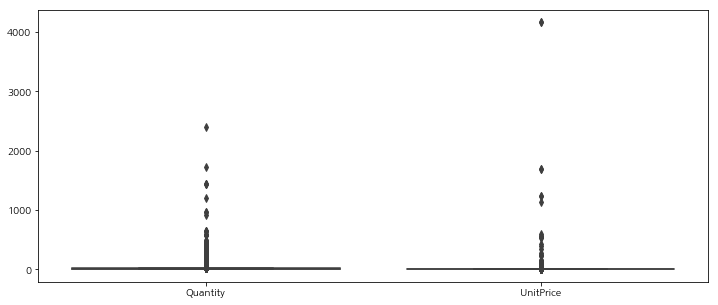

In [13]:
df1 = df1[df1['Quantity']>0]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df1[n_cols])
plt.show()

수량 하단의 0이하 값이 삭제된 것을 확인할 수 있다.

3.  **kmeans 또는 DBSCAN 등의 기법을 활용하여 군집을 생성하시오.**

dbscan은 eps(거리), 최소 샘플수 설정이 까다로우므로 kmeans 를 사용한다.  
또한 의미있는 모델링을 위해 파생변수를 추가한다.  
- 고객기준: 구매횟수, 구매액, 구매물품종류, 평균단가, 평균구매개수

In [14]:
df1.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,563808,22432,WATERING CAN PINK BUNNY,6.0,8/19/2011 11:46,1.95,12626.0,Germany
1,561645,23166,MEDIUM CERAMIC TOP STORAGE JAR,12.0,7/28/2011 15:16,1.25,14911.0,EIRE


In [15]:
add_f = df1.groupby('CustomerID').agg(b_freq = ('InvoiceNo', 'count'), 
                              m_price = ('UnitPrice', 'mean'),
                              n_code = ('StockCode', 'nunique'), 
                              m_q = ('Quantity', 'mean')).reset_index()

add_f['total'] = add_f['m_q'] * add_f['m_price'] * add_f['b_freq']
add_f.drop(columns=['m_q'], inplace=True)


df2 = pd.merge(df1, add_f, on='CustomerID', how='left')
df2.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,b_freq,m_price,n_code,total
0,563808,22432,WATERING CAN PINK BUNNY,6.0,8/19/2011 11:46,1.95,12626.0,Germany,293,2.823584,232,9721.598396
1,561645,23166,MEDIUM CERAMIC TOP STORAGE JAR,12.0,7/28/2011 15:16,1.25,14911.0,EIRE,5651,4.620269,1784,370434.685656


In [111]:
#kmeans 는 거리기반 클러스터링이니 연속형 변수 스케일링을 동일하게 맞춰주고
use_n_cols = ['b_freq', 'm_price', 'n_code', 'total']

train = df2[use_n_cols]

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

train = pd.DataFrame(sc.fit_transform(train), columns=train.columns)
train.head()

,b_freq,m_price,n_code,total
0,-0.481385,-0.384163,-0.374265,-0.581307
1,2.194414,0.180396,2.162878,1.587923
2,-0.495867,-0.031182,-0.428212,-0.587101
3,0.409549,-0.489115,0.390801,2.313330
4,-0.504357,-0.296175,-0.565531,-0.545329


In [112]:
#실루엣 평가
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ss = []
ll = [] #오차합

for i in range(2, 10):
    fit_km = KMeans(n_clusters=i, init='random', n_init=10, random_state=42).fit(train)
    s = silhouette_score(train, fit_km.labels_)
    ss.append(s)
    ll.append(fit_km.inertia_)
    print(f"클러스터수: {i} / 점수: {s:.2f} / 오차제곱합: {fit_km.inertia_:.3f}")

클러스터수: 2 / 점수: 0.78 / 오차제곱합: 49625.490
클러스터수: 3 / 점수: 0.80 / 오차제곱합: 27870.441
클러스터수: 4 / 점수: 0.71 / 오차제곱합: 18821.668
클러스터수: 5 / 점수: 0.79 / 오차제곱합: 6359.777
클러스터수: 6 / 점수: 0.81 / 오차제곱합: 3915.763
클러스터수: 7 / 점수: 0.61 / 오차제곱합: 2229.550
클러스터수: 8 / 점수: 0.54 / 오차제곱합: 1864.470
클러스터수: 9 / 점수: 0.56 / 오차제곱합: 1332.647


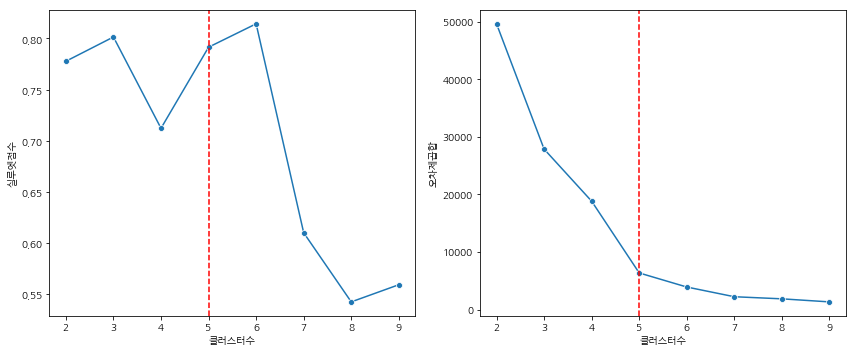

In [117]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.lineplot(x=np.arange(2, 10), y=ss, marker='o', ax=ax[0])
ax[0].set_xlabel('클러스터수')
ax[0].set_ylabel('실루엣점수')
ax[0].axvline(x=5, ls='--', color='r')

sns.lineplot(x=np.arange(2, 10), y=ll, marker='o', ax=ax[1])
ax[1].set_xlabel('클러스터수')
ax[1].set_ylabel('오차제곱합')
ax[1].axvline(x=5, ls='--', color='r')

plt.tight_layout()
plt.show()

실루엣 점수가 높을 수록, 오차제곱합이 낮을 수록 좋기 때문에, 적절한 지점을 찾는다.  
오차제곱합의 경우 elbow 지점인 k=5로 하거나 실루엣 점수가 높은 k=6으로 할 수 있다.
(너무 많은 군집으로 분류하면 해석이 어렵기 때문에 5로 한다.)

4.  **생성된 군집에 대하여 군집성능지표를 산출하고, 군집간 차이와 특성을 분석한 결과를 제시하시오.**

In [118]:
km = KMeans(n_clusters=5, random_state=42)
dist = km.fit_transform(train)
rs = km.labels_

In [120]:
from collections import Counter

print(Counter(rs))

center = pd.DataFrame(km.cluster_centers_, columns=train.columns, index=["cluster_"+ str(i) for i in range(5)])
display(center)

Counter({0: 24351, 1: 5651, 3: 3474, 2: 939, 4: 273})


,b_freq,m_price,n_code,total
cluster_0,-0.522240,-0.194038,-0.534835,-0.584688
cluster_1,2.194414,0.180396,2.162878,1.587923
cluster_2,-0.526513,2.350020,-0.519952,-0.513971
cluster_3,0.272989,-0.319896,0.398690,1.660765
cluster_4,-0.503739,9.561329,-0.349744,-0.082405


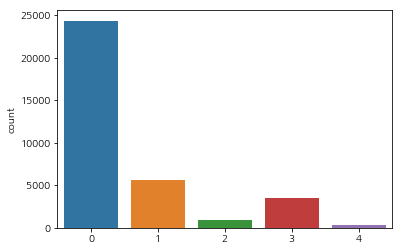

In [124]:
sns.countplot(rs)
plt.show()

0번 군집의 비율이 가장 많으며, 4번 군집이 가장 적다.

In [121]:
#실루엣 점수
s = silhouette_score(train, rs)
print(f"실루엣 점수: {s:.3f}")

실루엣 점수: 0.829


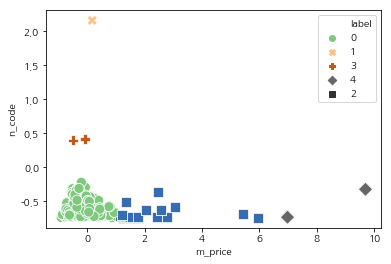

In [122]:
train['label'] = rs

sns.scatterplot(data=train, x='m_price', y='n_code', hue='label', style='label', s=100, palette='Accent')
plt.show()

다음으로는 원본 데이터를 기준으로 분석

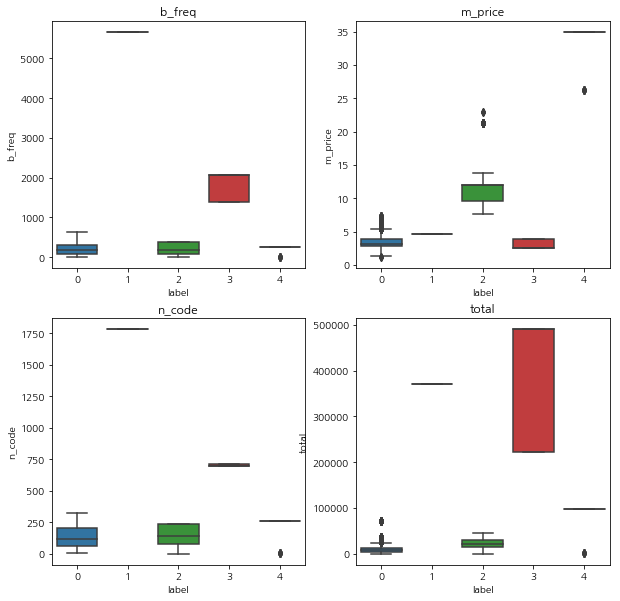

In [128]:
origin = df2[use_n_cols]
origin['label'] = rs

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for col, ax in zip(origin.columns[:-1], axes.flatten()):
    sns.boxplot(data=origin, x='label', y=col, ax=ax)
    ax.set_title(col)
plt.show()

In [129]:
for label in origin['label'].unique():
    print(f"<< 레이블 {label} >>")
    display(origin[origin['label'] == label].describe().T)

<< 레이블 0 >>


,count,mean,std,min,25%,50%,75%,max
b_freq,24351.0,211.190464,154.424835,3.000,85.000000,173.000000,308.000000,637.000000
m_price,24351.0,3.428651,0.945822,1.185,2.823584,3.202319,3.866578,7.282000
n_code,24351.0,133.777627,81.045303,3.000,59.000000,118.000000,205.000000,322.000000
total,24351.0,9159.432818,9190.766666,72.050,2900.357263,6849.539623,11670.077500,71814.339146
label,24351.0,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000


<< 레이블 1 >>


,count,mean,std,min,25%,50%,75%,max
b_freq,5651.0,5651.000000,0.000000e+00,5651.000000,5651.000000,5651.000000,5651.000000,5651.000000
m_price,5651.0,4.620269,8.882570e-16,4.620269,4.620269,4.620269,4.620269,4.620269
n_code,5651.0,1784.000000,0.000000e+00,1784.000000,1784.000000,1784.000000,1784.000000,1784.000000
total,5651.0,370434.685656,5.821281e-11,370434.685656,370434.685656,370434.685656,370434.685656,370434.685656
label,5651.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000


<< 레이블 3 >>


,count,mean,std,min,25%,50%,75%,max
b_freq,3474.0,1803.551526,333.470995,1397.000000,1397.000000,2077.000000,2077.000000,2077.000000
m_price,3474.0,3.028112,0.656739,2.489581,2.489581,2.489581,3.828776,3.828776
n_code,3474.0,704.825561,5.884782,700.000000,700.000000,700.000000,712.000000,712.000000
total,3474.0,382547.227737,132331.457220,221215.187974,221215.187974,491059.918902,491059.918902,491059.918902
label,3474.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000


<< 레이블 2 >>


,count,mean,std,min,25%,50%,75%,max
b_freq,939.0,202.635783,141.825133,2.000,84.000000,168.000000,370.000000,370.000000
m_price,939.0,11.525005,2.746927,7.695,9.665000,11.937946,11.937946,22.962500
n_code,939.0,142.881789,83.622884,2.000,76.000000,140.000000,236.000000,236.000000
total,939.0,20918.727444,11841.612221,91.850,15321.645545,20302.061786,28663.008216,45174.312647
label,939.0,2.000000,0.000000,2.000,2.000000,2.000000,2.000000,2.000000


<< 레이블 4 >>


,count,mean,std,min,25%,50%,75%,max
b_freq,273.0,248.238095,52.697441,13.00,260.000000,260.000000,260.000000,260.000000
m_price,273.0,34.474689,1.842474,26.25,34.885923,34.885923,34.885923,34.885923
n_code,273.0,247.000000,53.764191,7.00,259.000000,259.000000,259.000000,259.000000
total,273.0,92682.207253,20362.561722,1785.00,97227.067615,97227.067615,97227.067615,97227.067615
label,273.0,4.000000,0.000000,4.00,4.000000,4.000000,4.000000,4.000000


- 총 구매횟수(송장번호 기준), 구매한 물품 평균단가(어느정도 가격의 물품을 구매하는가?), 구매한 품목 갯수, 총 구매금액

- 총 구매횟수(송장번호 기준): 1번 군집의 총 구매횟수가 확연히 높다. 그 다음으로 3번 군집이 높으며,  
  중앙값 기준으로 군집 2가 가장 낮다. 4번 군집은 약 260회 정도에 몰려있다.
- 구매한 물품 평균단가: 군집 4가 가장 높으며, 그 다음으로 군집 2가 높고, 군집 3이 가장 낮다.   
  군집 1은 4.62 정도에 몰려있다.
- 구매한 품목 갯수: 군집 1이 가장 다양한 물품 구매, 군집 0이 가장 적은 품목 구매
- 총 구매금액: 군집 3의 총 구매금액은 범위가 넓으나 최소 221215원 ~ 최고 5만원 가까이의 물품을 구매하였음  
  군집1은 대다수의 사람들이 370434원 정도의 금액을 소비하였다. 구매력이 가장 낮은 군집은 0이다.
  
<종합>  
- 군집0: 대다수의 사람들에 해당, 대체로 낮은 단가의 물품을 낮은 빈도로 구매, 다양한 물품을 구매하지 않음
- 군집1: 저가의 아주 다양한 물품을 자주구매하는 충성고객, 총 구매액도 높은 편
- 군집2: 중저가의 물품을 낮은 빈도로 구매, 다양한 물품을 구매하지 않음
- 군집3: 저가의 비교적 다양한 물품을 중간 빈도로 구매하는 고객, 총 구매비용은 높은 편이며, 같은 군집 내에서 편차가 있는 편
- 군집4: 아주 고가의 물품을 낮은 빈도로 구매하는 고객, 구매하는 물품은 다양하지 않으며, 총 구매액도 낮음 편



5.  **군집별로 대표적인 추천상품을 구성하고, 군집별 추천 상품을 제시하고, 타군집과의 추천상품 차이를 설명하시오.**

In [139]:
p_cols = ['StockCode', 'Description', 'Quantity', 'UnitPrice']

tmp = df2[p_cols]

tmp = pd.concat([origin, tmp], axis=1)
tmp = tmp[['b_freq', 'm_price', 'n_code', 'total', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'label']]
tmp.head(3)

,b_freq,m_price,n_code,total,StockCode,Description,Quantity,UnitPrice,label
0,293,2.823584,232,9721.598396,22432,WATERING CAN PINK BUNNY,6.0,1.95,0
1,5651,4.620269,1784,370434.685656,23166,MEDIUM CERAMIC TOP STORAGE JAR,12.0,1.25,1
2,264,3.946932,199,8758.241705,20985,HEART CALCULATOR,12.0,1.25,0


In [170]:
for i in np.arange(5):
    codes = tmp[tmp['label'] == i]['StockCode'].value_counts()[:5].index
    tt = tmp[(tmp['label'] == i) & (tmp['StockCode'].isin(codes))][['StockCode', 'Description', 'Quantity', 'UnitPrice']].drop_duplicates()
    s_name = tt['Description'].unique()
    print(f"<<  군집 {i} >>")
    print(f"TOP 5 물품명: {s_name}")
    display(tt.head())

<<  군집 0 >>
TOP 5 물품명: ['POSTAGE' 'REGENCY CAKESTAND 3 TIER' 'PLASTERS IN TIN CIRCUS PARADE '
 'ROUND SNACK BOXES SET OF4 WOODLAND ' 'PLASTERS IN TIN WOODLAND ANIMALS']


,StockCode,Description,Quantity,UnitPrice
12,POST,POSTAGE,2.0,18.00
27,POST,POSTAGE,1.0,15.00
57,22423,REGENCY CAKESTAND 3 TIER,4.0,12.75
123,POST,POSTAGE,6.0,18.00
142,22556,PLASTERS IN TIN CIRCUS PARADE,24.0,1.65


<<  군집 1 >>
TOP 5 물품명: ['CARRIAGE' 'WHITE HANGING HEART T-LIGHT HOLDER'
 'ROSES REGENCY TEACUP AND SAUCER ' 'REGENCY CAKESTAND 3 TIER'
 'SMALL POPCORN HOLDER' 'POPCORN HOLDER']


,StockCode,Description,Quantity,UnitPrice
120,C2,CARRIAGE,1.0,50.00
190,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12.0,2.95
325,22699,ROSES REGENCY TEACUP AND SAUCER,24.0,2.55
366,22423,REGENCY CAKESTAND 3 TIER,6.0,12.75
392,22423,REGENCY CAKESTAND 3 TIER,3.0,12.75


<<  군집 2 >>
TOP 5 물품명: ['Manual' 'PLASTERS IN TIN SPACEBOY' 'PLASTERS IN TIN WOODLAND ANIMALS'
 'POSTAGE' 'LUNCH BAG DOILEY PATTERN ' 'LUNCH BAG VINTAGE DOILY ']


,StockCode,Description,Quantity,UnitPrice
370,M,Manual,2.0,1.25
445,22551,PLASTERS IN TIN SPACEBOY,12.0,1.65
583,22554,PLASTERS IN TIN WOODLAND ANIMALS,1.0,1.65
768,POST,POSTAGE,1.0,40.00
2790,POST,POSTAGE,4.0,28.00


<<  군집 3 >>
TOP 5 물품명: ['SPACEBOY LUNCH BOX ' 'REGENCY CAKESTAND 3 TIER' 'DOLLY GIRL LUNCH BOX'
 'SET OF 3 REGENCY CAKE TINS' 'ROUND SNACK BOXES SET OF4 WOODLAND ']


,StockCode,Description,Quantity,UnitPrice
111,22629,SPACEBOY LUNCH BOX,64.0,1.65
667,22423,REGENCY CAKESTAND 3 TIER,16.0,10.95
709,22630,DOLLY GIRL LUNCH BOX,2.0,1.95
796,23245,SET OF 3 REGENCY CAKE TINS,4.0,4.95
1232,22423,REGENCY CAKESTAND 3 TIER,32.0,10.95


<<  군집 4 >>
TOP 5 물품명: ['Manual' 'RECYCLED ACAPULCO MAT TURQUOISE' 'RECYCLED ACAPULCO MAT BLUE'
 'POSTAGE' 'RECYCLED ACAPULCO MAT RED']


,StockCode,Description,Quantity,UnitPrice
11942,M,Manual,1.0,4161.06
15622,23052,RECYCLED ACAPULCO MAT TURQUOISE,10.0,8.25
16331,23052,RECYCLED ACAPULCO MAT TURQUOISE,5.0,8.25
17584,23051,RECYCLED ACAPULCO MAT BLUE,8.0,8.25
20468,POST,POSTAGE,2.0,18.00


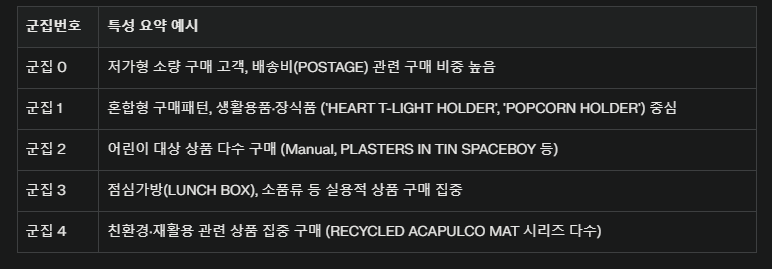

6.  **KNN을 활용하여 고객별 근접이웃분석을 수행하고 상품추천을 수행하는 방법을 기술하고, 구현하시오.**

In [208]:
train['CustomerID'] = df2['CustomerID'].astype('object')
train.head(2)

,b_freq,m_price,n_code,total,label,CustomerID
0,-0.481385,-0.384163,-0.374265,-0.581307,0,12626
1,2.194414,0.180396,2.162878,1.587923,1,14911


12473 고객의 이웃을 구한다. 먼저 어느 군집에 속하는지 확인한다. 

In [212]:
train[train['CustomerID'] == 12473]['label'].head(1)

39    2
Name: label, dtype: int32

2번 군집에 속한다. 다음으로 최근접 이웃을 5명 구한다. 

고객번호 '14911'의 이웃을 구한다. 해당고객은 충성고객층에 속하는 1번 군집이다.

In [215]:
ts = train[train['label'] == 2].drop_duplicates()
ts.head()

,b_freq,m_price,n_code,total,label,CustomerID
39,-0.543810,1.344169,-0.524663,-0.517679,2,12473
69,-0.593750,2.042819,-0.642365,-0.368104,2,12590
175,-0.442931,2.479775,-0.367726,-0.467399,2,12757
255,-0.577270,3.046457,-0.593322,-0.547630,2,12669
384,-0.585760,2.571096,-0.629287,-0.593882,2,12783


In [217]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=6) #이웃 5
rs = knn.fit(ts.iloc[:, :-2])

In [223]:
dist, indices = rs.kneighbors(ts.iloc[:, :-2])

indices = indices[:, 1:].reshape(-1)
c_idx = ts['CustomerID'].iloc[indices].to_numpy()
c_idx = pd.DataFrame(c_idx.reshape(-1, 5))
c_idx.columns = ['k1', 'k2', 'k3', 'k4', 'k5']
c_idx.index = ts['CustomerID']

c_idx.head()

,k1,k2,k3,k4,k5
CustomerID,,,,,
12473.0,12791,12384,12547,12445,12795
12590.0,12401,12603,12464,12757,12504
12757.0,12783,12464,13493,12590,12669
12669.0,13493,12783,12464,12757,12590
12783.0,12464,13493,12757,12669,12590


In [244]:
n_id = c_idx.head(1).values[0].

n_df = df2[['StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']]

for i in n_id:
    codes = n_df[n_df['CustomerID'] == i]['StockCode'].value_counts()[:5].index
    tt = n_df[(n_df['StockCode'].isin(codes))][['StockCode', 'Description', 'Quantity', 'UnitPrice']].drop_duplicates()
    s_name = tt['Description'].unique()
    print(f"<<  고객번호 {i} >>")
    print(f"TOP 5 물품명: {s_name}")
    display(tt.head())

<<  고객번호 12473 >>
TOP 5 물품명: ['POSTAGE' 'RIBBON REEL POLKADOTS ' 'Manual'
 'ROUND SNACK BOXES SET OF4 WOODLAND ' 'PACK 3 BOXES BIRD PANNETONE ']


,StockCode,Description,Quantity,UnitPrice
12,POST,POSTAGE,2.0,18.00
27,POST,POSTAGE,1.0,15.00
100,22080,RIBBON REEL POLKADOTS,10.0,1.65
123,POST,POSTAGE,6.0,18.00
151,POST,POSTAGE,5.0,28.00


<<  고객번호 12791.0 >>
TOP 5 물품명: ['POSTAGE' 'HAND WARMER BIRD DESIGN']


,StockCode,Description,Quantity,UnitPrice
12,POST,POSTAGE,2.0,18.0
27,POST,POSTAGE,1.0,15.0
123,POST,POSTAGE,6.0,18.0
151,POST,POSTAGE,5.0,28.0
240,POST,POSTAGE,2.0,28.0


<<  고객번호 12384.0 >>
TOP 5 물품명: ['POSTAGE' 'ROUND SNACK BOXES SET OF4 WOODLAND ' 'JUMBO BAG STRAWBERRY'
 'MINI LIGHTS WOODLAND MUSHROOMS' 'TRADITIONAL WOODEN CATCH CUP GAME ']


...

,StockCode,Description,Quantity,UnitPrice
12,POST,POSTAGE,2.0,18.00
27,POST,POSTAGE,1.0,15.00
123,POST,POSTAGE,6.0,18.00
151,POST,POSTAGE,5.0,28.00
164,21080,SET/20 RED RETROSPOT PAPER NAPKINS,12.0,0.85


<<  고객번호 12445.0 >>
TOP 5 물품명: ['POSTAGE' '3 WHITE CHOC MORRIS BOXED CANDLES'
 'CLASSIC CHROME BICYCLE BELL ' 'CLASSIC CROME BICYCLE BELL '
 '3 ROSE MORRIS BOXED CANDLES']


,StockCode,Description,Quantity,UnitPrice
12,POST,POSTAGE,2.0,18.0
27,POST,POSTAGE,1.0,15.0
123,POST,POSTAGE,6.0,18.0
151,POST,POSTAGE,5.0,28.0
240,POST,POSTAGE,2.0,28.0


<<  고객번호 12795.0 >>
TOP 5 물품명: ['RABBIT NIGHT LIGHT' 'ROSES REGENCY TEACUP AND SAUCER '
 'BOX OF 6 CHRISTMAS CAKE DECORATIONS' 'TV DINNER TRAY AIR HOSTESS '
 'SUNFLOWER DECORATIVE PARASOL']


,StockCode,Description,Quantity,UnitPrice
156,23084,RABBIT NIGHT LIGHT,96.0,1.79
237,23084,RABBIT NIGHT LIGHT,12.0,2.08
325,22699,ROSES REGENCY TEACUP AND SAUCER,24.0,2.55
660,23084,RABBIT NIGHT LIGHT,18.0,2.08
743,23084,RABBIT NIGHT LIGHT,6.0,2.08


12473 고객에게 최근접 이웃 5명의 TOP 5 물품을 구매추천한다.


## 문제 2 (25회 기출)

**Data description**

우리나라에 입국한 관광객 수에 관한 데이터입니다.

-   train : 1981.1 \~ 1991.12
-   test : 1992.1 \~ 1992.12
#### 데이터 셋:problem2.csv

1.  **데이터를 탐색하시오.**

In [328]:
df2 = pd.read_csv('./problem2.csv')
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   144 non-null    object 
 1   value   140 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB
None


In [329]:
df2.reset_index(inplace=True, drop=True)
df2['index'] = df2['index'].astype('datetime64')
df2['index'] = df2['index'].dt.strftime('%Y-%m')
df2.set_index('index', inplace=True, drop=True)
df2.head()

,value
index,
1981-01,67745.0
1981-02,68478.0
1981-03,85521.0
1981-04,105884.0
1981-05,110425.0


2.  **결측치 확인 및 결측치를 대치하시오.**

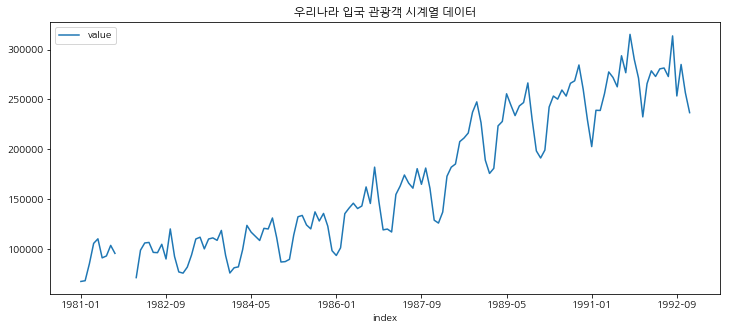

In [330]:
df2.plot(figsize = (12, 5))
plt.title('우리나라 입국 관광객 시계열 데이터')
plt.show()

In [331]:
df2[df2['value'].isna()]

,value
index,
1981-10,NaN
1981-11,NaN
1981-12,NaN
1982-01,NaN


1981년10월부터 1982년 1월까지 4개의 결측치가 존재한다.   
선형보간을 실시한다. 

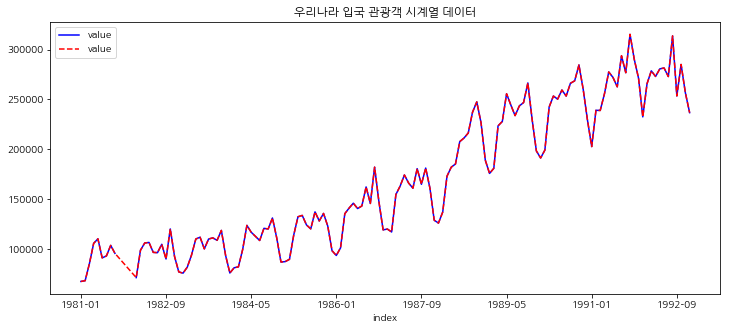

In [332]:
df3 = df2.interpolate(method='linear')

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
df2.plot(ax=ax, color='b', ls='-', label='원본', legend=True)
df3.plot(ax=ax, color='r', ls='--', label='보간', legend=True)
plt.title('우리나라 입국 관광객 시계열 데이터')
plt.legend()
plt.show()

In [371]:
train = df3.head(-12)
test = df3.tail(12)

train.shape, test.shape

((132, 1), (12, 1))

3.  **계절성을 포함하는 시계열 모델을 구축하고 정확도 측면에서 제시하시오.**

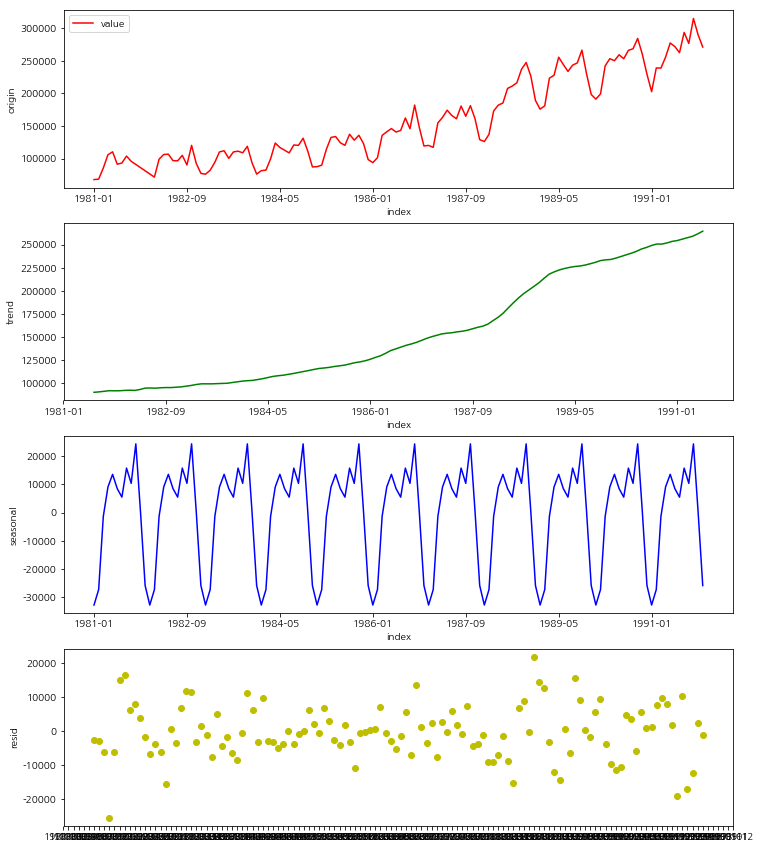

In [372]:
#일단 stl 분해를 통해 계절성 확인

from statsmodels.tsa.seasonal import seasonal_decompose
#년단위 데이터로 12

def check_g(data):
    model = seasonal_decompose(data, model='additive', period=12)
    resid = model.resid
    seasonal = model.seasonal
    trend = model.trend

    title = ['origin', 'trend', 'seasonal', 'resid']
    dt_list = [data, trend, seasonal, resid]
    col_list = ['r', 'g', 'b','y']

    fig, ax = plt.subplots(4, 1, figsize=(12, 15))

    for t, dt, ax, c in zip(title, dt_list, ax, col_list):
        if t == 'resid':
            ax.scatter(x=dt.index, y=dt, color=c)
        else:
            dt.plot(ax=ax, color=c)
        ax.set_ylabel(t)
    plt.show()
check_g(train)

- 추세는 시간에 따라 증가
- 일정한 파형의 계절성 추세 관찰됨
- 잔차는 랜덤 노이즈 형태로 시간축을 따라 불규칙하게 분포

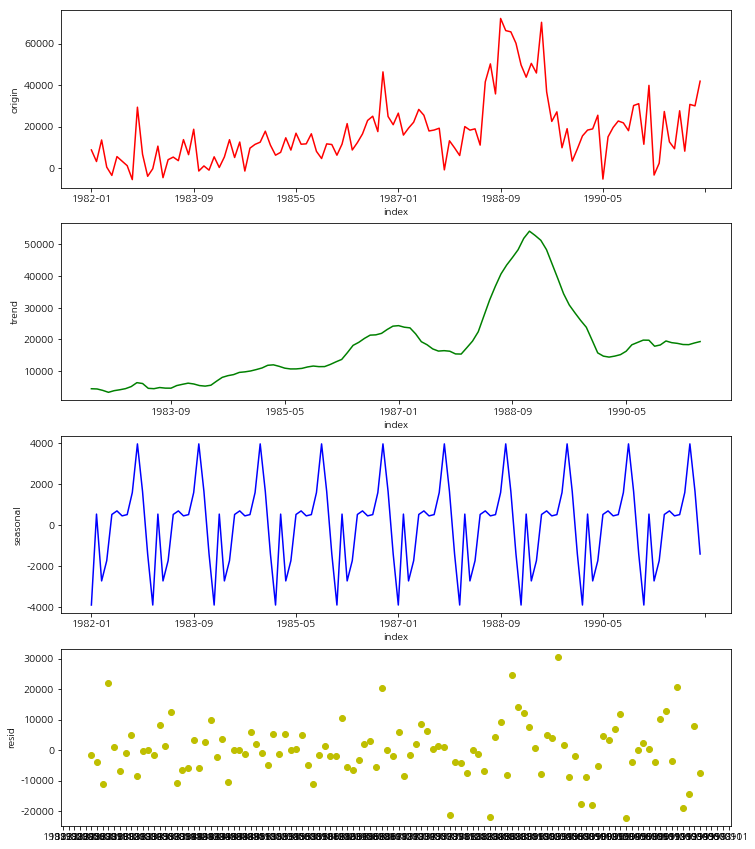

In [404]:
#계절차분을 먼저 수행: 12
train['s_diff'] = train['value'].diff(12)

check_g(train['s_diff'].dropna())

In [405]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf


def ck_s(data):
    f_list = [adfuller, kpss]
    title = ['adfuller', 'kpss']
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    for f, t in zip(f_list, title):
        rs = f(data)
        print(f"유의수준 5% 하 {t} 통계량: {rs[0]:.3f} / p-value: {rs[1]:.3f}")
        plot_acf(dt.dropna(), lags=36, ax=ax[0])
        plot_pacf(dt.dropna(), lags=36, ax=ax[1])
    plt.show()

유의수준 5% 하 adfuller 통계량: 1.186 / p-value: 0.996
유의수준 5% 하 kpss 통계량: 1.867 / p-value: 0.010


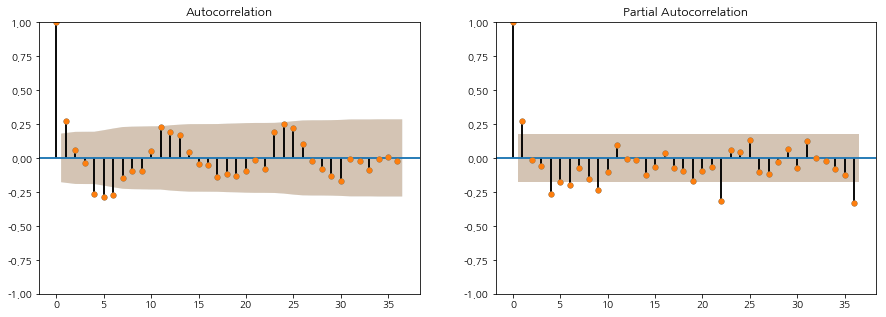

유의수준 5% 하 adfuller 통계량: -1.556 / p-value: 0.505
유의수준 5% 하 kpss 통계량: 0.832 / p-value: 0.010


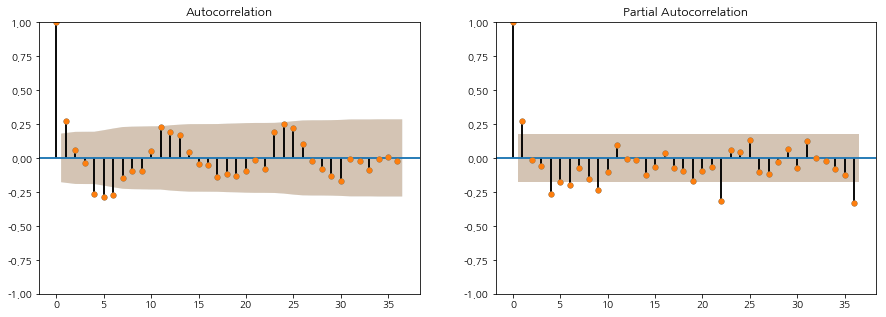

In [406]:
ck_s(train['value'])
ck_s(train['s_diff'].dropna())

계절성 추세는 제거된 것으로 보이나 아직 정상성을 만족하지 못하므로 차분을 수행한다.

유의수준 5% 하 adfuller 통계량: -4.958 / p-value: 0.000
유의수준 5% 하 kpss 통계량: 0.130 / p-value: 0.100


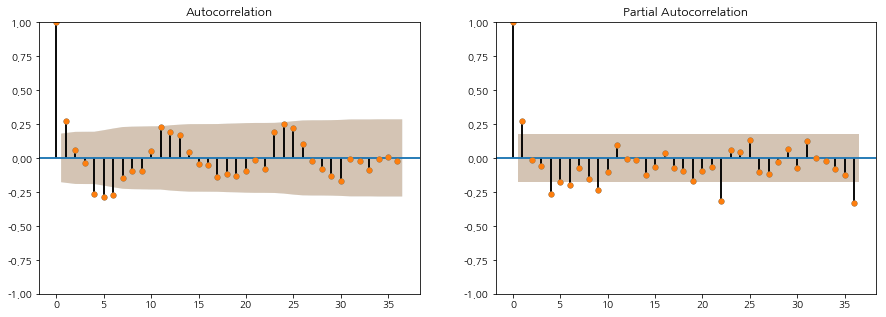

In [407]:
train['diff'] = train['s_diff'].diff(1)

ck_s(train['diff'].dropna())

In [ ]:
일반차분 1회 이후 정상성을 만족한다. 

- 계절차수(s, P, Q, d) →12, 1, 1, 12
- 일반차수(p, q, d) → 1, 1, 1

4.  **업무에 적용할 수 있는지, 판단근거와 함께 서술하시오.**

## 문제 3(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학 연구소에서 연구원으로 일하고 있습니다. 그는 직업 만족도가 사람들의 수입 수준에 따라 어떻게 달라지는지 궁금했습니다. 이를 위해 도시에서 일하는 96명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사에서는 응답자들의 수입과 직업 만족도에 대해 물어보았고, 그 결과는 다음과 같았습니다.


| 수입\직업만족도   | **VD (매우 불만족)** | **LD (조금 불만족)** | **MS (조금 만족)** | **VS (매우 만족)** |
|------------------|---------------------|----------------------|--------------------|---------------------|
| **<15,000**      |          1          |          3           |        10          |         6           |
| **15,000-25,000**|          2          |          3           |        10          |         7           |
| **25,000-40,000**|          1          |          6           |        14          |        12           |
| **>40,000**      |          0          |          1           |         9          |        11           |


1.  **수입 수준과 직업 만족도 간의 순위 관계를 파악하기 위해 Goodman and Kruskal의 Gamma 계수를 계산하시오.**

gamma = (P-Q) / (P+Q)   
- P: 순위가 일치하는 쌍의 수
- Q: 순위가 불일치하는 쌍의 수

P: 두 쌍 비교 시 수입도 증가하고, 직업만족도도 증가하는 경우 쌍의 개수((1,1) 과 (2, 2) 쌍 비교)  
Q: 두 쌍 비교 시 수입은 증가하나, 직업만족도는 감소하는 경우 쌍의 개수((1, 2)와 (2, 1) 쌍 비교)  

**<해석>**  

- 범위: -1 <= G <= 1
- G = 1: 완전한 순위 일치(강한 양의 상관관계)
- G = -1: 완전한 순위 불일치(강한 음의 상관관계)
- G = 0: 순위간 무상관(동점은 계산에서 제외)

In [11]:
data = {
    "수입": ["<15,000", "15,000-25,000", "25,000-40,000", ">40,000"],
    "VD": [1, 2, 1, 0],      # 매우 불만족
    "LD": [3, 3, 6, 1],      # 조금 불만족
    "MS": [10, 10, 14, 9],   # 조금 만족
    "VS": [6, 7, 12, 11]     # 매우 만족
}
df = pd.DataFrame(data)
df = df.set_index('수입') #반드시 인덱스 설정해야 함

In [16]:
from itertools import product

P = 0 #순위일치 쌍 수
Q = 0 #순위 불일치 쌍 수

for (i1, j1), (i2, j2) in product(np.ndindex(df.shape), repeat=2):
    if (i1 < i2) & (j1 < j2): # 수입도 증가하고, 직업만족도도 증가하는 경우
        P += df.iloc[i1, j1] * df.iloc[i2, j2]
    elif (i1 < i2) & (j1 > j2):
        Q += df.iloc[i1, j1] * df.iloc[i2, j2]
        
#gamma 계산
g = (P-Q)/(P+Q)

print(f"순위일치쌍 수: {P} / 순위 불일치쌍 수: {Q}")
print(f"goodman and kruscal gamma 계수: {g}")

순위일치쌍 수: 1331 / 순위 불일치쌍 수: 849
goodman and kruscal gamma 계수: 0.22110091743119267


In [17]:
# z = (p-q)/np.sqrt(p+q)

from scipy.stats import norm

z = (P-Q)/np.sqrt(P+Q)
p = (1-norm.cdf(abs(z)))*2

print(f"z 검정통계량 {z:.3f} / p-value: {p:.3f}")

z 검정통계량 10.323 / p-value: 0.000


유의확률 5% 하에서 귀무가설 기각, 즉 두 변수 간에는 순위상관관계가 있음


## 문제 4

**별도의 데이터 없음**

슬통 전구회사는 자사의 제품 생산 라인에서 최근 불량률이 급증했다는 내부 보고서를 받았습니다. 초기 보고서에 따르면 불량률이 약 9%에 달한다고 합니다. 회사의 경영진은 이를 확인하기 위해 독립적인 품질 검사팀에 조사를 의뢰하였습니다. 검사팀은 신뢰도 95%로 불량률을 확인하기 위해 필요한 표본 크기를 계산하고자 합니다. 오차한계가 3% 내외로 허용된다면, 검사팀은 최소 몇 개의 제품을 표본으로 선택해야 하는지 계산하시오.

In [22]:
#z분포 모비율 추정 표본갯수 문제
p = 0.09 #모비율
a = 1-0.95
me = 0.03

z = norm.ppf(1-a/2)
s_size = (p*(1-p))/np.square(me/z)

print(f"최소 개수: {np.ceil(s_size)}")

최소 개수: 350.0




## 문제 5(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학을 공부하는 대학생으로, 학력 수준에 따라 사람들이 어떤 종교적 신념을 가지고 있는지 궁금해졌습니다. 이를 알아보기 위해, 도시에서 일하는 2726명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사 응답 결과를 정리한 자료는 다음과 같습니다.

| 학위\\종교적 믿음 | 원리주의자 | 중도 | 원칙주의자 |
|-------------------|------------|------|------------|
| 고졸              | 178        | 138  | 108        |
| 전문대졸          | 570        | 648  | 442        |
| 대졸              | 138        | 252  | 252        |



In [23]:
df = pd.DataFrame([[178, 138, 108], 
                  [570, 648, 442], 
                  [138, 252, 252]], 
                 index=['고졸', '전문대졸', '대졸'], 
                 columns = ['원리주의자', '중도', '원칙주의자'])
display(df)

,원리주의자,중도,원칙주의자
고졸,178,138,108
전문대졸,570,648,442
대졸,138,252,252


1.  **5% 유의수준에서 가설 검증에 대한 검정통계량을 계산하시오. (단, 반올림하여 소수점 셋째 자리까지 표시하시오.) 연구가설의 채택여부를 결정하시오.**

해당 문제는 종속변수와 독립변수가 모두 명목형 변수이며, 각 변수가 3개의 집단을 가지고 한 변수에 따라 다른변수가 어떠한 영향이 있는지 확인하는 문제이므로, 비모수검정인 카이제곱 독립성 검정(한 모집단이므로)이 적절해보인다. 

- H0: 학위와 종교적 믿음은 독립적이다.(연관이 없다.)
- H1: 학위와 종교적 믿음은 상호관계가 있다.(통계적으로 연관이 있다.)

유의확률 5% 하에서 검정을 실시한다.

In [25]:
from scipy.stats import chi2_contingency 

stats, p, ddof, expected = chi2_contingency(df)

print(f"p_value: {p:.3f}")

p_value: 0.000


유의확률 5% 하에서 카이제곱 독립성 검정 p-value가 0에 가까우므로, 귀무가설을 기각한다.  
따라서 학위와 종교적 믿음은은 연관관계가 있고, 통계적으로 유의하다.

2.  **검정 결과에 대한 잔차분석을 수행하고, 해석하시오.**

In [36]:
# 표준화 잔차
resid = df.values - expected
s_resid = pd.DataFrame(resid / np.sqrt(expected), index=df.index, columns=df.columns)

print("표준화잔차")
display(s_resid)

표준화잔차


,원리주의자,중도,원칙주의자
고졸,3.423775,-1.845523,-1.499038
전문대졸,1.311771,0.632781,-2.098646
대졸,-4.891737,0.482291,4.592852


표준화 잔차는 절대값이 2 이상이면 통계적으로 유의하므로,  
- 고졸-원리주의자, 전문대졸-원칙주의자, 대졸-(원리주의자, 원칙주의자)가 통계적으로 유의



## 문제 6

슬통 초등학교에서는 학생들의 건강 관리를 위해 일부 학생들의 혈압을 측정하였습니다. 총 25명의 학생 중 남학생은 16명, 여학생은 9명이었습니다. 학교 건강 관리팀은 남학생과 여학생 사이에 평균 혈압이 차이가 있는지 궁금해하였고, 이를 확인하기 위해 5%의 유의수준에서 검정하려 합니다. (단, 남녀 학생의 혈압이 정규분포를 따르며, 두 집단의 분산이 동일하다고 가정합니다.)

#### 데이터 셋:problem6.csv

In [61]:
df = pd.read_csv('problem6.csv').set_index('No.')
df.head()

,남학생,여학생
No.,,
1,124.97,114.87
2,118.62,128.14
3,126.48,115.92
4,135.23,110.88
5,117.66,139.66


1)  **연구가설과 귀무가설 작성하시오.**

한 모집단 측정값(독립성)을 가지고 두 집단 간의 평균차이 여부를 검정하는 문제이며, 정규성과 등분산성을 가정하였기 때문에 t-test 검정을 실시한다. 

유의확률 5% 하에서,  
- H0: 남학생과 여학생의 평균의 차가 없다.
- H1: 남학생과 여학생의 평균의 차이가 있다. 


2)  **가설검증에 대한 검정통계량을 계산하고, 연구가설의 채택여부를 설명하시오.**

In [62]:
from scipy.stats import ttest_ind

stats, p = ttest_ind(df['남학생'], df['여학생'].dropna()) #2샘플 독립표본 검정

print(f"ttest 검정결과: {p:.3f}")

ttest 검정결과: 0.773


유의확률 5% 하 귀무가설을 기각할 수 없으므로, 남학생과 여학생의 평균의 차가 없다.

3)  **가설검정에 대한 신뢰구간을 계산하고, 계산된 신뢰구간이 어떻게 2의 결과를 지지하는지 설명하시오.\
    (단, 신뢰구간 계산시 다음의 값을 사용하시오.)**

-   $t_{23,0.025} = 2.069$

In [63]:
f_mean = df['여학생'].mean()
m_mean = df['남학생'].mean()
var1 = df['여학생'].var(ddof=1)
var2 = df['남학생'].var(ddof=1)
dof1 = len(df['여학생'].dropna()) -1
dof2 = len(df['남학생']) -1

diff = m_mean  - f_mean 
df = dof1+dof2
pv =(dof1*var1 + dof2*var2)/df

se = np.sqrt(pv)*np.sqrt(1/(dof1+1)+1/(dof2+1))
t = 2.069
me = t*se

print(f"구간추정량: {diff-me:.3f} ~ {diff+me:.3f}")

구간추정량: -9.424 ~ 7.095


두 집단의 평균의 차는 약 1.16으로 95% 신뢰구간(-7.095 ~ 9.424) 내 포함되므로 두 집단의 평균의 차이는 없다. 또한 신뢰구간 내 0이 포함되어 있으므로 두 그룹의 평균차이가 유의하지 않다고 볼 수 있다.

## 문제 7

### 다음은 1월부터 9월까지의 은의 가격이다
![image](https://github.com/Datamanim/datarepo/blob/main/adp/26/problem2.png?raw=true)

In [70]:
df4 = pd.DataFrame({'month' : [1,2,3,4,5,6,7,8,9],'price' : [12.14,42.6,34.4,35.29,30.96,57.12,37.84,42.49,31.38]})
df4.set_index('month', inplace=True)

1) **은의 가격 및 이동평균값 3이 설정된 시계열 그래프를 그려라**

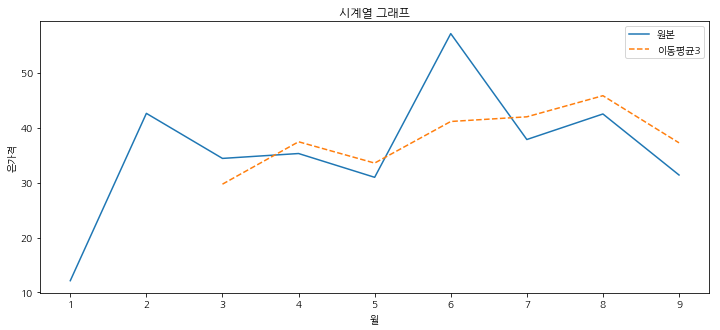

In [72]:
roll_3 = df4.rolling(window=3).mean().dropna()
dt_list = [df4, roll_3]
title = ['원본', '이동평균3']

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for dt, title, ls in zip(dt_list, title, ['-', '--']):
    ax.plot(dt, label=title, ls=ls)
plt.legend()
plt.title('시계열 그래프')
plt.xlabel('월')
plt.ylabel('은가격')
plt.show()

2) **1월 대비 9월의 은의 가격은 몇 % 올랐는가? 소수점 두번째 자리에서 반올림**

In [76]:
seq = 31.38
jan = 12.14
diff = seq-jan
p = diff/jan*100

print(f"은의 가격은 {p:.2f} %상승")

은의 가격은 158.48 %상승


## 문제 8

### height(키), weight(몸무게), waist(허리둘레) 컬럼을 가진 problem7.csv파일을 가지고 다음을 분석하라.
A시의 20대 남성 411명을 임의로 추출하여 키, 몸무게, 허리둘레를 조사하여 기록한 데이터이다.      
이 데이터를 이용하여 20대 남성의 키와 허리둘레가 체중에 영향을 미치는지 알아보고자 한다

In [77]:
df = pd.read_csv('https://raw.githubusercontent.com/TKV-JONGIN/DataSet/refs/heads/main/ADP_26_problem7.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   height     411 non-null    float64
 1   weight     411 non-null    float64
 2   waistline  411 non-null    float64
dtypes: float64(3)
memory usage: 9.8 KB


,height,weight,waistline
0,174.396,72.102,79.3787
1,179.656,81.255,80.6649
2,175.079,76.207,80.3166
3,180.804,81.354,80.8794
4,177.448,78.768,80.3499


1) **아래 조건을 참고하여 회귀계수(반올림하여 소수점 두자리)를 구하시오.**
- 베이지안 회귀
- 시드넘버 1234로 지정
- 1000번의 burn-in 이후 10,000의 MCMC를 수행
- 회귀계수의 사전분포는 부적절한 균일분포(inproper uniform prior distribution), 오차항의 분산의 사전분포는 역감마 분포로 지정. 이때, 형상(Shape)모수와 척도(Scale)모수는 각각 0.005로 지정.

In [83]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split

x = df.drop(columns=['weight'])
y = df['weight']

train_X, test_X, train_Y, test_Y = train_test_split(x, y, random_state=1234)

bays = BayesianRidge(n_iter=1000, fit_intercept=False, lambda_1 = 0.005, lambda_2 = 0.005)
bays.fit(train_X, train_Y)

print(bays.coef_)
print(bays.score(test_X, test_Y))

[ 1.12069702 -1.51558217]
0.674069432703238


2) **위1)에서 만든 모델을 바탕으로 키 180cm, 허리둘레 85cm인 남성의 몸무게를 추정하라**

In [96]:
bays.predict([[180, 85]])

array([72.90097939])

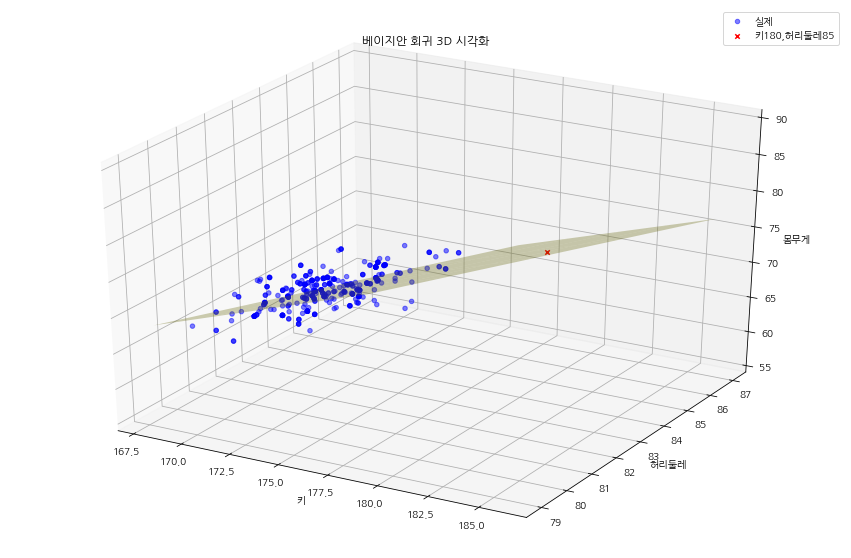

In [154]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(df['height'], df['waistline'], df['weight'], color='b', alpha=0.5, label='실제')

height_grid, waist_grid = np.meshgrid(
    np.linspace(168, 186, 5),
    np.linspace(79, 87, 5)
)
pred = bays.coef_[0]*height_grid + bays.coef_[1]*waist_grid
ax.plot_surface(height_grid, waist_grid, pred, color='y', alpha=0.3)
ax.scatter(180, 85, bays.predict([[180, 85]]), color='r', marker='x', alpha=1, label='키180,허리둘레85')

ax.legend()
ax.set_title('베이지안 회귀 3D 시각화')
ax.set_xlabel('키')
ax.set_ylabel('허리둘레')
ax.set_zlabel('몸무게')
plt.show()

In [171]:
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

# 실제 데이터 산점도
scatter = go.Scatter3d(
    x=df['height'], y=df['waistline'], z=df['weight'], mode='markers',
    name='실제 데이터', marker=dict(size=4, color='blue', opacity=0.7)
)


height_grid, waist_grid = np.meshgrid(
    np.linspace(168, 186, 5),
    np.linspace(79, 87, 5)
)
pred = bays.coef_[0]*height_grid + bays.coef_[1]*waist_grid

surface = go.Surface(
    x=height_grid, y=waist_grid, z=pred,
    name='회귀 평면', opacity=0.3, showscale=False
)

scatter2 = go.Scatter3d(
    x=[180], y=[85], z=bays.predict([[180, 85]]), mode='markers',
    name='예측값', marker=dict(size=4, color='red', opacity=1)
)
    
layout = go.Layout(
    title='인터랙티브 3D 선형회귀 플롯',
    scene=dict(
        xaxis=dict(title='키'),
        yaxis=dict(title='허리둘레'),
        zaxis=dict(title='몸무게')
    )
)
fig = go.Figure(data=[scatter, surface, scatter2], layout=layout)
init_notebook_mode(connected=True)  # Jupyter에서 필요
iplot(fig)